# TP Bioinformatique COVID-19 - Partie 4
## Alignement des reads sur le génome de référence

**Auteur : Marwa zidi**

**Durée estimée : 35 minutes**

### Objectifs
- Comprendre le principe de l'alignement de reads
- Utiliser BWA ou Bowtie2 pour aligner les séquences
- Manipuler les fichiers SAM/BAM
- Évaluer la qualité des alignements

---

In [2]:
# Import des bibliothèques
import os
import subprocess
import pysam
import matplotlib.pyplot as plt
import numpy as np

print("✅ Bibliothèques chargées")

✅ Bibliothèques chargées


## 1. Principe de l'alignement

### Qu'est-ce que l'alignement ?
L'alignement consiste à **positionner les reads** (courtes séquences) sur le **génome de référence**.

### Algorithmes courants
- **BWA** (Burrows-Wheeler Aligner) : Rapide, précis, standard
- **Bowtie2** : Performant pour reads courts
- **Minimap2** : Pour reads longs (PacBio, Nanopore)

### Pipeline
```
FASTQ → [Indexation génome] → [Alignement] → SAM → BAM (trié + indexé)
```

### Formats de fichiers
- **SAM** (Sequence Alignment Map) : Format texte
- **BAM** : Version binaire compressée du SAM
- **BAI** : Index du fichier BAM

## 2. Indexation du génome de référence

Avant d'aligner, il faut **indexer** le génome de référence.

Cette étape crée une structure de données permettant l'alignement rapide.

In [3]:
# Chemins des fichiers
reference_genome = "/opt/covid_data/NC_045512.2.fasta"
output_dir = os.path.expanduser("~/notebooks-covid/alignment")
os.makedirs(output_dir, exist_ok=True)

print("📁 Vérification des fichiers...")
print(f"   Génome de référence : {reference_genome}")
print(f"   Existe : {os.path.exists(reference_genome)}")

# Indexation avec BWA (si pas déjà fait)
if os.path.exists(reference_genome):
    index_files = [f"{reference_genome}.{ext}" for ext in ['amb', 'ann', 'bwt', 'pac', 'sa']]
    
    if not all(os.path.exists(f) for f in index_files):
        print("\n🔧 Indexation du génome avec BWA...")
        cmd = f"bwa index {reference_genome}"
        result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
        
        if result.returncode == 0:
            print("✅ Indexation réussie")
        else:
            print(f"❌ Erreur : {result.stderr}")
    else:
        print("\n✅ Index BWA déjà présent")
else:
    print("⚠️ Génome de référence non trouvé")

📁 Vérification des fichiers...
   Génome de référence : /opt/covid_data/NC_045512.2.fasta
   Existe : True

✅ Index BWA déjà présent


## 3. Alignement avec BWA

### Commande BWA MEM
```bash
bwa mem reference.fasta reads.fastq > alignment.sam
```

**Options importantes :**
- `-t` : Nombre de threads (CPU)
- `-M` : Mark shorter split hits as secondary (compatibilité Picard/GATK)
- `-R` : Read group (métadonnées)

In [4]:
# Alignement BWA
fastq_file = "/opt/covid_data/sample_reads.fastq"
sam_file = f"{output_dir}/alignment.sam"

if os.path.exists(fastq_file) and os.path.exists(reference_genome):
    print("🧬 Lancement de l'alignement BWA MEM...\n")
    
    # Commande BWA avec read group
    cmd = f"""
    bwa mem -t 2 \
    -R '@RG\\tID:covid_sample\\tSM:SARS-CoV-2\\tPL:ILLUMINA' \
    {reference_genome} {fastq_file} > {sam_file}
    """
    
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    
    if result.returncode == 0:
        print("✅ Alignement terminé")
        print(f"📄 Fichier SAM créé : {sam_file}")
        
        # Taille du fichier
        size_mb = os.path.getsize(sam_file) / (1024 * 1024)
        print(f"📏 Taille : {size_mb:.2f} MB")
    else:
        print(f"❌ Erreur : {result.stderr}")
else:
    print("⚠️ Fichiers manquants pour l'alignement")
    print("\n💡 Commande typique :")
    print("   bwa mem genome.fasta reads.fastq > alignment.sam")

🧬 Lancement de l'alignement BWA MEM...

✅ Alignement terminé
📄 Fichier SAM créé : /root/notebooks-covid/alignment/alignment.sam
📏 Taille : 27.11 MB


## 4. Format SAM : Structure

Le fichier SAM contient :
1. **En-tête** (lignes commençant par @)
2. **Alignements** (1 ligne par read)

### Colonnes principales (11 obligatoires)
| Colonne | Nom | Description |
|---------|-----|-------------|
| 1 | QNAME | Nom du read |
| 2 | FLAG | Indicateurs d'alignement (bitwise) |
| 3 | RNAME | Nom du chromosome/contig |
| 4 | POS | Position de début (1-based) |
| 5 | MAPQ | Qualité de mapping (0-60) |
| 6 | CIGAR | Chaîne d'alignement |
| 10 | SEQ | Séquence du read |
| 11 | QUAL | Qualités Phred |

### Flags importants
- **0** : Read aligné normalement
- **4** : Read non aligné (unmapped)
- **16** : Read sur brin complémentaire reverse
- **256** : Alignement secondaire
- **2048** : Alignement supplémentaire

In [5]:
# Visualisation du fichier SAM
if os.path.exists(sam_file):
    print("📖 Aperçu du fichier SAM :\n")
    
    with open(sam_file, 'r') as f:
        lines = f.readlines()
        
    # Affichage de l'en-tête
    print("🔹 EN-TÊTE :")
    header_lines = [l for l in lines if l.startswith('@')][:5]
    for line in header_lines:
        print(f"   {line.strip()}")
    
    # Affichage de quelques alignements
    print(f"\n🔹 PREMIERS ALIGNEMENTS (sur {len([l for l in lines if not l.startswith('@')])} total) :")
    alignment_lines = [l for l in lines if not l.startswith('@')][:3]
    
    for i, line in enumerate(alignment_lines, 1):
        fields = line.strip().split('\t')
        if len(fields) >= 11:
            print(f"\n   Alignement #{i} :")
            print(f"      QNAME (nom)  : {fields[0]}")
            print(f"      FLAG         : {fields[1]}")
            print(f"      RNAME (chr)  : {fields[2]}")
            print(f"      POS          : {fields[3]}")
            print(f"      MAPQ         : {fields[4]}")
            print(f"      CIGAR        : {fields[5]}")
            print(f"      SEQ (début)  : {fields[9][:50]}...")
else:
    print("⚠️ Fichier SAM non trouvé")

📖 Aperçu du fichier SAM :

🔹 EN-TÊTE :
   @SQ	SN:NC_045512.2	LN:29903
   @RG	ID:covid_sample	SM:SARS-CoV-2	PL:ILLUMINA
   @PG	ID:bwa	PN:bwa	VN:0.7.17-r1188	CL:bwa mem -t 2 -R @RG\tID:covid_sample\tSM:SARS-CoV-2\tPL:ILLUMINA /opt/covid_data/NC_045512.2.fasta /opt/covid_data/sample_reads.fastq

🔹 PREMIERS ALIGNEMENTS (sur 50662 total) :

   Alignement #1 :
      QNAME (nom)  : SRR11140744.1
      FLAG         : 16
      RNAME (chr)  : NC_045512.2
      POS          : 221
      MAPQ         : 60
      CIGAR        : 251M
      SEQ (début)  : TCATCAGCACATCTAGGTTTCGTCCGGGTGTGACCGAAAGGTAAGATGGA...

   Alignement #2 :
      QNAME (nom)  : SRR11140744.2
      FLAG         : 16
      RNAME (chr)  : NC_045512.2
      POS          : 114
      MAPQ         : 60
      CIGAR        : 238M
      SEQ (début)  : GTGCACTCACGCAGTATAATTAATAACTAATTACTGTCGTTGACAGGACA...

   Alignement #3 :
      QNAME (nom)  : SRR11140744.3
      FLAG         : 16
      RNAME (chr)  : NC_045512.2
      POS          : 222
  

## 5. Conversion SAM → BAM et tri

Le format **BAM** est la version binaire compressée du SAM.

### Avantages du BAM
- **Taille réduite** (compression)
- **Indexation possible** (.bai)
- **Accès rapide** aux régions spécifiques

### Pipeline de conversion
```bash
samtools view -bS alignment.sam > alignment.bam
samtools sort alignment.bam -o alignment_sorted.bam
samtools index alignment_sorted.bam
```

In [6]:
# Conversion et tri avec SAMtools
if os.path.exists(sam_file):
    bam_file = f"{output_dir}/alignment.bam"
    sorted_bam = f"{output_dir}/alignment_sorted.bam"
    
    print("🔄 Conversion SAM → BAM...")
    cmd1 = f"samtools view -bS {sam_file} > {bam_file}"
    subprocess.run(cmd1, shell=True)
    print("✅ BAM créé")
    
    print("\n📊 Tri du fichier BAM...")
    cmd2 = f"samtools sort {bam_file} -o {sorted_bam}"
    subprocess.run(cmd2, shell=True)
    print("✅ BAM trié")
    
    print("\n🗂️ Indexation du BAM...")
    cmd3 = f"samtools index {sorted_bam}"
    subprocess.run(cmd3, shell=True)
    print("✅ Index créé (.bai)")
    
    # Comparaison des tailles
    sam_size = os.path.getsize(sam_file) / (1024 * 1024)
    bam_size = os.path.getsize(sorted_bam) / (1024 * 1024)
    
    print(f"\n📏 Tailles de fichiers :")
    print(f"   SAM  : {sam_size:.2f} MB")
    print(f"   BAM  : {bam_size:.2f} MB")
    print(f"   Compression : {(1 - bam_size/sam_size)*100:.1f}%")
    
    # Nettoyage des fichiers intermédiaires
    os.remove(bam_file)
    print("\n🧹 Fichiers intermédiaires supprimés")
else:
    print("⚠️ Pas de fichier SAM à convertir")

🔄 Conversion SAM → BAM...
✅ BAM créé

📊 Tri du fichier BAM...
✅ BAM trié

🗂️ Indexation du BAM...
✅ Index créé (.bai)

📏 Tailles de fichiers :
   SAM  : 27.11 MB
   BAM  : 3.27 MB
   Compression : 87.9%

🧹 Fichiers intermédiaires supprimés


## 6. Statistiques d'alignement

Analysons la qualité de l'alignement avec `samtools flagstat` et `samtools stats`.

In [7]:
# Statistiques avec flagstat
sorted_bam = f"{output_dir}/alignment_sorted.bam"

if os.path.exists(sorted_bam):
    print("📊 STATISTIQUES D'ALIGNEMENT\n")
    print("=" * 60)
    
    # Flagstat
    result = subprocess.run(f"samtools flagstat {sorted_bam}", 
                          shell=True, capture_output=True, text=True)
    print(result.stdout)
    
    # Extraction du taux d'alignement
    lines = result.stdout.split('\n')
    for line in lines:
        if 'mapped' in line and '%' in line:
            print(f"\n🎯 {line.strip()}")
            break
    
    print("=" * 60)
else:
    print("⚠️ Fichier BAM non trouvé")

📊 STATISTIQUES D'ALIGNEMENT

50662 + 0 in total (QC-passed reads + QC-failed reads)
50000 + 0 primary
0 + 0 secondary
662 + 0 supplementary
0 + 0 duplicates
0 + 0 primary duplicates
50662 + 0 mapped (100.00% : N/A)
50000 + 0 primary mapped (100.00% : N/A)
0 + 0 paired in sequencing
0 + 0 read1
0 + 0 read2
0 + 0 properly paired (N/A : N/A)
0 + 0 with itself and mate mapped
0 + 0 singletons (N/A : N/A)
0 + 0 with mate mapped to a different chr
0 + 0 with mate mapped to a different chr (mapQ>=5)


🎯 50662 + 0 mapped (100.00% : N/A)


## 7. Analyse avec pysam (Python)

Utilisons **pysam** pour lire et analyser le fichier BAM directement en Python.

📈 Analyse de 10,000 reads :

   Reads mappés : 10,000 (100.00%)
   Reads non mappés : 0
   MAPQ moyen : 60.0
   MAPQ médian : 60


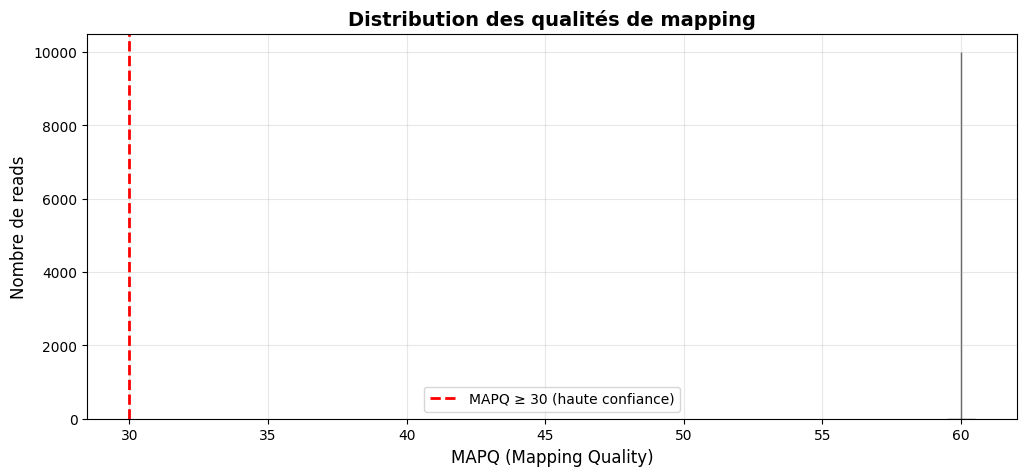


✅ Reads avec MAPQ ≥ 30 : 10,000 (100.0%)


In [8]:
# Lecture du BAM avec pysam
if os.path.exists(sorted_bam):
    bamfile = pysam.AlignmentFile(sorted_bam, "rb")
    
    # Statistiques manuelles
    total_reads = 0
    mapped_reads = 0
    mapq_scores = []
    
    for read in bamfile:
        total_reads += 1
        if not read.is_unmapped:
            mapped_reads += 1
            mapq_scores.append(read.mapping_quality)
        
        # Limiter l'analyse pour la démonstration
        if total_reads >= 10000:
            break
    
    bamfile.close()
    
    # Résultats
    print(f"📈 Analyse de {total_reads:,} reads :\n")
    print(f"   Reads mappés : {mapped_reads:,} ({mapped_reads/total_reads*100:.2f}%)")
    print(f"   Reads non mappés : {total_reads - mapped_reads:,}")
    print(f"   MAPQ moyen : {np.mean(mapq_scores):.1f}")
    print(f"   MAPQ médian : {np.median(mapq_scores):.0f}")
    
    # Distribution MAPQ
    plt.figure(figsize=(12, 5))
    plt.hist(mapq_scores, bins=60, edgecolor='black', alpha=0.7, color='steelblue')
    plt.axvline(x=30, color='red', linestyle='--', linewidth=2, label='MAPQ ≥ 30 (haute confiance)')
    plt.xlabel('MAPQ (Mapping Quality)', fontsize=12)
    plt.ylabel('Nombre de reads', fontsize=12)
    plt.title('Distribution des qualités de mapping', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Interprétation MAPQ
    high_quality = sum(1 for q in mapq_scores if q >= 30)
    print(f"\n✅ Reads avec MAPQ ≥ 30 : {high_quality:,} ({high_quality/len(mapq_scores)*100:.1f}%)")
else:
    print("⚠️ Fichier BAM non disponible")

## 8. Interprétation des résultats

### MAPQ (Mapping Quality)
- **MAPQ = 60** : Alignement unique et parfait
- **MAPQ ≥ 30** : Haute confiance (99.9% de probabilité d'être correct)
- **MAPQ < 20** : Faible confiance (alignements ambigus)
- **MAPQ = 0** : Plusieurs alignements possibles (multimapping)

### Critères de qualité
✅ **> 95% de reads mappés** : Excellent  
✅ **> 80% avec MAPQ ≥ 30** : Très bonne qualité  
⚠️ **< 70% de reads mappés** : Problème potentiel (contamination, mauvaise référence)

## 📝 Points clés

✅ **Indexation** : Étape obligatoire avant alignement  
✅ **BWA MEM** : Algorithme standard pour Illumina  
✅ **SAM → BAM** : Compression et indexation indispensables  
✅ **MAPQ ≥ 30** : Critère de qualité pour filtrage  
✅ Taux de mapping > 95% = données de qualité

---

**➡️ Passez au notebook suivant : `05_Visualisation_Couverture.ipynb`**